**STA761: Quantifying University Eligibility**  
Name: Sreyams Sathyan  
Student Number: 4246471  


1) Two separate logistic regression models — one for Western Cape candidates and one for North West candidates — each reporting predictor significance and a multicollinearity (VIF) check.
2) One decision tree built on the combined candidates from both provinces.
3) Candidates with different subject combinations (e.g. Accounting + Life Sciences + Physical Sciences, or no science electives at all) are kept in the modelling data — the model is no longer restricted to only those who took Physical Sciences, Life Sciences and Information Technology.
4) Candidates who took Mathematical Literacy are removed from the modelling data, since Mathematical Literacy automatically disqualifies a candidate from BSc Mathematical Statistics eligibility (pure Mathematics is compulsory). See the note below for one extra decision made on top of this.

    Modelling-population decision (flagging this explicitly): the raw data contains three groups — candidates with a Mathematics mark, candidates with a Mathematical Literacy mark, and a small group with neither (missing exam/incomplete records). Every single candidate in the "neither" group is already coded Eligible_UWC_or_NWU = 0 in the data (no pure Maths -> automatically not eligible, exactly like the Mathematical Literacy rule). Since these candidates carry no information for a model trying to explain what separates eligible from non-eligible candidates, they are excluded together with the Mathematical Literacy group. In practice, this means the modelling population is simply every candidate who has a recorded Mathematics_Mark. This is verified explicitly in the code below -- nothing is assumed silently.


## 1) Import all Libraries

In [1]:
# ============================================
# 1. LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
RANDOM_STATE = 123

In [2]:
# ============================================
# 2. LOAD DATA
# ============================================
# Set file path
file_path = "C:/Users/Administrator/Desktop/STA 761/ResearchProject/4265563_BSc_MathStats_UWC_NWU_Eligibility.xlsx"

# Read Excel file
data = pd.read_excel(file_path, sheet_name="Candidate_summary")

# Initial inspection
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106726 entries, 0 to 106725
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Candidate_id                 106726 non-null  int64         
 1   Data_Source                  106726 non-null  object        
 2   Centre_id                    106726 non-null  int64         
 3   Centre_type                  106726 non-null  object        
 4   Province                     106726 non-null  object        
 5   Exam_Date                    106726 non-null  int64         
 6   DOB                          106726 non-null  datetime64[ns]
 7   Gender                       106726 non-null  object        
 8   Race                         106726 non-null  object        
 9   NR                           106726 non-null  int64         
 10  Num_Subjects_Recorded        106726 non-null  int64         
 11  NSC_Admission_Category    

,Candidate_id,Data_Source,Centre_id,Centre_type,Province,Exam_Date,DOB,Gender,Race,NR,Num_Subjects_Recorded,NSC_Admission_Category,Level_Obtained,NSC_Bachelors_Pass,English_Mark,Second_Language_Mark,Mathematics_Mark,Mathematical_Literacy_Mark,Life_Orientation_Mark,Physical_Sciences_Mark,Life_Sciences_Mark,Information_Technology_Mark,UWC_APS,UWC_Subject_Met,UWC_APS_Met,UWC_Eligible,NWU_APS,NWU_Subjects_Counted,NWU_Subject_Met,NWU_APS_Met,NWU_Eligible,Eligible_UWC_or_NWU
0,1000001,WC,101001,Public,Western Cape,202511,2007-08-13,Female,Coloured,7,7,Bachelors,Qualification achieved,1,56.0,61.0,NaN,64.0,62,NaN,NaN,NaN,36,0,1,0,27,6,0,1,0,0
1,1000002,WC,101001,Public,Western Cape,202511,2005-11-03,Female,Coloured,7,7,Bachelors,Qualification achieved,1,65.0,68.0,NaN,61.0,60,NaN,NaN,NaN,36,0,1,0,26,6,0,1,0,0
2,1000003,WC,101001,Public,Western Cape,202511,2007-08-10,Female,Coloured,7,7,Bachelors,Qualification achieved,1,70.0,75.0,NaN,74.0,71,NaN,69.0,NaN,47,0,1,0,35,6,0,1,0,0
3,1000004,WC,101001,Public,Western Cape,202511,2007-04-15,Female,Coloured,7,7,Bachelors,Qualification achieved,1,56.0,57.0,NaN,67.0,57,NaN,40.0,NaN,36,0,1,0,27,6,0,1,0,0
4,1000005,WC,101001,Public,Western Cape,202511,2007-06-17,Female,Coloured,7,7,Bachelors,Qualification achieved,1,52.0,65.0,NaN,55.0,62,NaN,NaN,NaN,35,0,1,0,27,6,0,1,0,0


## 2.1 Correlation heatmap (raw numeric fields)

Kept from the original notebook, purely as an initial exploratory step. `Exam_Date` and `NWU_Subjects_Counted` are dropped here only because they add no information to a correlation heatmap (`Exam_Date` is a constant/ID-like field, `NWU_Subjects_Counted` is an admin count). They are **not** dropped from the modelling data itself later on.

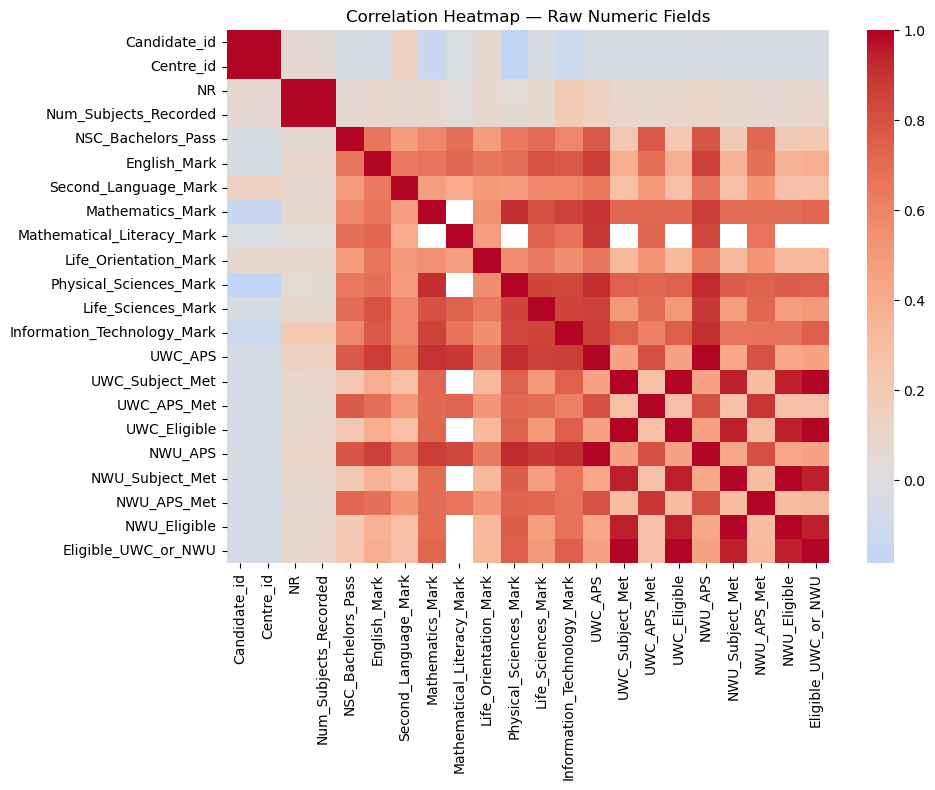

In [4]:
numeric_data = data.drop(columns=['Exam_Date', 'NWU_Subjects_Counted']).select_dtypes(include=np.number)
cor_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Raw Numeric Fields")
plt.tight_layout()
plt.show()

## 3. The Mathematical Literacy rule

A candidate who wrote Mathematical Literacy cannot be eligible for BSc Mathematical Statistics, regardless of what the raw `Eligible_UWC_or_NWU` flag says, because pure Mathematics is a compulsory admission subject. We first build the indicator and confirm how it interacts with the maths variables.

In [5]:
# Create indicator for candidates who took Mathematics Literacy
# 1 -> candidate took Mathematics Literacy
# 0 -> candidate did not take Mathematics Literacy
data["Math_Lit"] = data["Mathematical_Literacy_Mark"].notna().astype(int)

print(data["Math_Lit"].value_counts())

Math_Lit
1    76842
0    29884
Name: count, dtype: int64


In [6]:
# Four possible combinations of (Mathematics_Mark present, Mathematical_Literacy_Mark present)
math_status = pd.crosstab(
    data["Mathematics_Mark"].notna(),
    data["Mathematical_Literacy_Mark"].notna(),
    rownames=["Has Mathematics_Mark"],
    colnames=["Has Mathematical_Literacy_Mark"]
)
print(math_status)

Has Mathematical_Literacy_Mark  False  True 
Has Mathematics_Mark                        
False                            3397  76842
True                            26487      0


Notice the `False / False` cell: **3,397 candidates have neither a Mathematics mark nor a Mathematical Literacy mark**. As explained above, we check next whether the maths-literacy rule and this "neither" group actually change anything relative to the eligibility flag already in the data.

In [7]:
# Create eligibility variable enforcing the Mathematics Literacy rule
data["Eligibility_MathRule"] = np.where(
    data["Math_Lit"] == 1,
    0,
    data["Eligible_UWC_or_NWU"]
)

# Were any Mathematical Literacy candidates originally (incorrectly) coded as eligible?
invalid = data[(data["Math_Lit"] == 1) & (data["Eligible_UWC_or_NWU"] == 1)]
print("Math Literacy candidates originally coded as eligible:", len(invalid))

# What about the 'neither' group -- are any of them coded as eligible?
no_maths_at_all = data[(data["Mathematics_Mark"].isna()) & (data["Mathematical_Literacy_Mark"].isna())]
print("'Neither' group candidates coded as eligible:", (no_maths_at_all["Eligible_UWC_or_NWU"] == 1).sum())
print("'Neither' group size:", len(no_maths_at_all))

Math Literacy candidates originally coded as eligible: 0
'Neither' group candidates coded as eligible: 0
'Neither' group size: 3397


Both checks come back at **0** — the data already treats both groups as automatically ineligible. That confirms `Eligibility_MathRule` and the raw `Eligible_UWC_or_NWU` agree everywhere once we restrict to candidates who actually wrote pure Mathematics. So the modelling population is defined simply as:

**Modelling population = candidates with a non-missing `Mathematics_Mark`.**

This removes both the Mathematical Literacy candidates *and* the small "neither" group in one step, and — importantly — does **not** touch which science electives a candidate took. A candidate who did Accounting, Life Sciences and Physical Sciences (no IT) stays in; a candidate who did Physical Sciences, Life Sciences and IT stays in; a candidate who took none of the three science electives (e.g. Accounting + Geography) also stays in.

In [8]:
# ============================================
# 3.1 Build the modelling population
# ============================================
model_pop = data[data["Mathematics_Mark"].notna()].copy()

print("Full dataset size:                 ", len(data))
print("Modelling population size:         ", len(model_pop))
print("Modelling population by province:")
print(model_pop["Province"].value_counts())
print()
print("Eligibility rate by province (modelling population):")
print(model_pop.groupby("Province")["Eligible_UWC_or_NWU"].mean().round(3))

Full dataset size:                  106726
Modelling population size:          26487
Modelling population by province:
Province
Western Cape    15926
North West      10561
Name: count, dtype: int64

Eligibility rate by province (modelling population):
Province
North West      0.119
Western Cape    0.224
Name: Eligible_UWC_or_NWU, dtype: float64


As expected, the dataset **shrinks substantially** (from ~106,700 to ~26,500 candidates) once Mathematical Literacy / no-Maths candidates are excluded — but the shrinkage happens through the compulsory-Maths rule, not through requiring specific science electives. We still have candidates with every subject combination.

A tiny number of candidates (well under 1%) are missing `English_Mark` or `Second_Language_Mark`. These are dropped via listwise deletion since imputing core language marks is not defensible and the loss is negligible.

In [9]:
before_n = len(model_pop)
model_pop = model_pop.dropna(subset=["English_Mark", "Second_Language_Mark"]).copy()
print(f"Dropped {before_n - len(model_pop)} candidates missing English/Second-language marks "
      f"({(before_n - len(model_pop)) / before_n:.3%} of the modelling population)")
print("Modelling population size after this step:", len(model_pop))

Dropped 69 candidates missing English/Second-language marks (0.261% of the modelling population)
Modelling population size after this step: 26418


## 4. Handling the science electives (Physical Sciences / Life Sciences / Information Technology)

Because different candidates choose different subjects, `Physical_Sciences_Mark`, `Life_Sciences_Mark` and `Information_Technology_Mark` are **structurally missing** for a candidate who simply didn't take that subject — this is not the same thing as "missing data" in the usual sense, and it should not be imputed with a mean or dropped via `dropna()` (which is what the original notebook did, and which is exactly the restriction we're removing).

Instead, for each of the three subjects we create:
- a **`Took_<Subject>`** indicator (1 = candidate wrote that subject, 0 = candidate did not), and
- the mark itself, with missing values (i.e. "did not take") filled with **0**.

This lets the model use both *whether* a candidate took the subject and *how well* they did in it if they did, without discarding candidates who chose a different subject combination.

In [10]:
for subject_mark in ["Physical_Sciences_Mark", "Life_Sciences_Mark", "Information_Technology_Mark"]:
    took_flag = "Took_" + subject_mark.replace("_Mark", "")
    model_pop[took_flag] = model_pop[subject_mark].notna().astype(int)
    model_pop[subject_mark] = model_pop[subject_mark].fillna(0)

print(model_pop[["Took_Physical_Sciences", "Took_Life_Sciences", "Took_Information_Technology"]].sum())
print()
print("Subject-combination sizes (True = took subject):")
print(model_pop.groupby(["Took_Physical_Sciences", "Took_Life_Sciences", "Took_Information_Technology"]).size())

Took_Physical_Sciences         19647
Took_Life_Sciences             19492
Took_Information_Technology     1002
dtype: int64

Subject-combination sizes (True = took subject):
Took_Physical_Sciences  Took_Life_Sciences  Took_Information_Technology
0                       0                   0                               3449
                                            1                                155
                        1                   0                               3109
                                            1                                 58
1                       0                   0                               2848
                                            1                                474
                        1                   0                              16010
                                            1                                315
dtype: int64


Information Technology is a rare subject choice (only ~1,000 of ~26,400 candidates), so `Information_Technology_Mark` / `Took_Information_Technology` will carry a wide confidence interval — this is flagged again at the multicollinearity and results stage.

## 5. Choosing predictors

**Excluded from the predictor set (data leakage):** `UWC_APS`, `UWC_Subject_Met`, `UWC_APS_Met`, `UWC_Eligible`, `NWU_APS`, `NWU_Subjects_Counted`, `NWU_Subject_Met`, `NWU_APS_Met`, `NWU_Eligible`, `NSC_Admission_Category`, `Level_Obtained`. These are all derived directly from the target or from the same exam marks used to compute the target (`Eligible_UWC_or_NWU`), so including them would make the "model" trivially predict itself rather than reveal which marks/behaviours drive eligibility.  

**Excluded from the predictor set (fairness):** `Race`. Including a racial classification as a predictor in a university-eligibility model risks reproducing/encoding historical demographic disparities as if they were causal drivers of eligibility, which is not the purpose of this analysis. `Gender` and `Centre_type` (Public/Independent) are kept as structural/contextual controls, since these reflect institutional context rather than a protected demographic classification used to *judge* an individual candidate. If your research question is specifically about demographic disparities in eligibility, `Race` can be added back in — it is left in `model_pop` for that purpose, simply not in the `predictors` list below.

**Excluded (redundant):** `NR`. A quick check shows `NR` and `Num_Subjects_Recorded` are correlated at **0.99** (they disagree on only 42 of 106,726 candidates) — they are effectively the same variable, so only `Num_Subjects_Recorded` is retained. This redundancy is exactly the kind of thing the VIF check below is designed to catch.

**Final predictor set**:

In [19]:
model_pop["Centre_type_Independent"] = (model_pop["Centre_type"] == "Independent").astype(int)
model_pop["Gender_Male"] = (model_pop["Gender"] == "Male").astype(int)

predictors = [
    "English_Mark",
    "Second_Language_Mark",
    "Mathematics_Mark",
    "Life_Orientation_Mark",
    "Physical_Sciences_Mark",
    "Took_Physical_Sciences",
    "Life_Sciences_Mark",
    "Took_Life_Sciences",
    "Information_Technology_Mark",
    "Took_Information_Technology",
    "Num_Subjects_Recorded",
    "Centre_type_Independent",
    "Gender_Male",
]

target = "Eligible_UWC_or_NWU"   # identical to Eligibility_MathRule within model_pop -- see check below
print("Sanity check -- Eligibility_MathRule matches Eligible_UWC_or_NWU within model_pop:",
      (model_pop["Eligibility_MathRule"] == model_pop[target]).all())

print("Number of predictors:", len(predictors))
predictors

Sanity check -- Eligibility_MathRule matches Eligible_UWC_or_NWU within model_pop: True
Number of predictors: 13


['English_Mark',
 'Second_Language_Mark',
 'Mathematics_Mark',
 'Life_Orientation_Mark',
 'Physical_Sciences_Mark',
 'Took_Physical_Sciences',
 'Life_Sciences_Mark',
 'Took_Life_Sciences',
 'Information_Technology_Mark',
 'Took_Information_Technology',
 'Num_Subjects_Recorded',
 'Centre_type_Independent',
 'Gender_Male']

## 6. Split into provinces, then train / validation split

Each province gets its own train/validation split (70/30, stratified on eligibility to preserve the class balance) so that the two logistic regression models are entirely independent of one another.

In [20]:
wc_data = model_pop[model_pop["Province"] == "Western Cape"].copy()
nw_data = model_pop[model_pop["Province"] == "North West"].copy()

def make_split(df, name):
    X = df[predictors]
    y = df[target]
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    print(f"{name}: {len(df)} candidates -> {len(X_train)} train / {len(X_val)} validation "
          f"(eligibility rate: train={y_train.mean():.3f}, val={y_val.mean():.3f})")
    return X_train, X_val, y_train, y_val

WC_X_train, WC_X_val, WC_y_train, WC_y_val = make_split(wc_data, "Western Cape")
NW_X_train, NW_X_val, NW_y_train, NW_y_val = make_split(nw_data, "North West")

Western Cape: 15867 candidates -> 11106 train / 4761 validation (eligibility rate: train=0.224, val=0.223)
North West: 10551 candidates -> 7385 train / 3166 validation (eligibility rate: train=0.119, val=0.119)


## 7. Multicollinearity check (Variance Inflation Factor)

VIF is computed separately for each province on the **training** predictors (a constant is added since VIF for the intercept is not meaningful). A common rule of thumb: VIF > 10 signals problematic multicollinearity, and VIF > 5 is worth a closer look.

In [22]:
def compute_vif(X_train, name):
    Xc = sm.add_constant(X_train)
    vif = pd.DataFrame()
    vif["feature"] = Xc.columns
    vif["VIF"] = [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
    vif = vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
    print(f"--- VIF: {name} ---")
    print(vif.to_string(index=False))
    print()
    return vif

wc_vif = compute_vif(WC_X_train, "Western Cape")
nw_vif = compute_vif(NW_X_train, "North West")


--- VIF: Western Cape ---
                    feature       VIF
Information_Technology_Mark 17.442806
Took_Information_Technology 16.935012
         Life_Sciences_Mark 10.828712
         Took_Life_Sciences 10.316303
     Physical_Sciences_Mark  8.359743
     Took_Physical_Sciences  5.195260
           Mathematics_Mark  4.316949
               English_Mark  3.188119
      Life_Orientation_Mark  2.004731
       Second_Language_Mark  1.920638
                Gender_Male  1.254661
      Num_Subjects_Recorded  1.044662
    Centre_type_Independent  1.034192

--- VIF: North West ---
                    feature       VIF
Information_Technology_Mark 14.157789
Took_Information_Technology 13.972149
         Life_Sciences_Mark  9.248907
     Physical_Sciences_Mark  8.936793
         Took_Life_Sciences  7.785358
     Took_Physical_Sciences  5.036814
           Mathematics_Mark  3.822967
               English_Mark  2.878753
       Second_Language_Mark  1.755243
      Life_Orientation_Mark  1.687533

**Reading the VIF table:** `Information_Technology_Mark` and `Took_Information_Technology` come out elevated (roughly 13–18) in both provinces. This is a structural side-effect of how they were built — the mark is exactly 0 whenever the flag is 0 — combined with IT being a very rare subject choice (~4% of candidates), which makes the two variables move together more than usual. The same, milder, pattern shows up for the Physical Sciences / Life Sciences pairs. None of the *other* predictors show concerning VIF values (all comfortably under 5), and `Num_Subjects_Recorded` in particular is now well-behaved once the redundant `NR` column is dropped. If you want a stricter cut, the simplest fix is to drop `Took_Information_Technology` and rely on `Information_Technology_Mark` alone (0 already encodes "did not take"); both variables are left in below for interpretability, with this caveat noted in the conclusion.

## 8. Logistic Regression — Western Cape

Predictor significance is reported using `statsmodels` (on standardised predictors, so coefficients are comparable in magnitude), and a separate `scikit-learn` pipeline is used for prediction/evaluation on the validation set, mirroring the structure of the original notebook.

In [23]:
# --- Significance table (statsmodels) ---
wc_scaler = StandardScaler()
WC_X_train_scaled = pd.DataFrame(
    wc_scaler.fit_transform(WC_X_train), columns=predictors, index=WC_X_train.index
)
WC_X_train_scaled_c = sm.add_constant(WC_X_train_scaled)

wc_logit = sm.Logit(WC_y_train, WC_X_train_scaled_c).fit(method="newton", maxiter=500, disp=0)
print(wc_logit.summary())

                            Logit Regression Results                           
Dep. Variable:     Eligible_UWC_or_NWU   No. Observations:                11106
Model:                           Logit   Df Residuals:                    11092
Method:                            MLE   Df Model:                           13
Date:                 Thu, 17 Sep 2026   Pseudo R-squ.:                  0.8491
Time:                         22:48:19   Log-Likelihood:                -890.75
converged:                        True   LL-Null:                       -5901.6
Covariance Type:             nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -7.4355      0.257    -28.937      0.000      -7.939      -6.932
English_Mark                   -0.1329      0.121     -1.102      0.271 

**Note on the "quasi-separation" warning:** `Mathematics_Mark` is such a strong driver of eligibility (APS/subject-requirement cut-offs are computed largely from these same marks) that a majority of candidates can be perfectly classified by it alone. This is a real, substantive feature of the data — Mathematics performance essentially gate-keeps eligibility — rather than a coding error, but it does mean the standard errors/p-values for variables that overlap with that separation boundary should be read with some caution rather than taken at face value.

In [24]:
# --- Prediction / evaluation (scikit-learn) ---
wc_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])
wc_logistic_model.fit(WC_X_train, WC_y_train)

wc_y_pred = wc_logistic_model.predict(WC_X_val)
wc_y_prob = wc_logistic_model.predict_proba(WC_X_val)[:, 1]

print("Western Cape logistic regression -- validation performance")
print("Accuracy: ", accuracy_score(WC_y_val, wc_y_pred))
print("Precision:", precision_score(WC_y_val, wc_y_pred))
print("Recall:   ", recall_score(WC_y_val, wc_y_pred))
print("ROC-AUC:  ", roc_auc_score(WC_y_val, wc_y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(WC_y_val, wc_y_pred))
print("\nClassification Report:")
print(classification_report(WC_y_val, wc_y_pred))

Western Cape logistic regression -- validation performance
Accuracy:  0.966183574879227
Precision: 0.9192200557103064
Recall:    0.9304511278195489
ROC-AUC:   0.9945373306135232

Confusion Matrix:
[[3610   87]
 [  74  990]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3697
           1       0.92      0.93      0.92      1064

    accuracy                           0.97      4761
   macro avg       0.95      0.95      0.95      4761
weighted avg       0.97      0.97      0.97      4761



## 9. Logistic Regression — North West

Same procedure, applied independently to the North West candidates.

In [25]:
nw_scaler = StandardScaler()
NW_X_train_scaled = pd.DataFrame(
    nw_scaler.fit_transform(NW_X_train), columns=predictors, index=NW_X_train.index
)
NW_X_train_scaled_c = sm.add_constant(NW_X_train_scaled)

nw_logit = sm.Logit(NW_y_train, NW_X_train_scaled_c).fit(method="newton", maxiter=500, disp=0)
print(nw_logit.summary())

                            Logit Regression Results                           
Dep. Variable:     Eligible_UWC_or_NWU   No. Observations:                 7385
Model:                           Logit   Df Residuals:                     7371
Method:                            MLE   Df Model:                           13
Date:                 Thu, 17 Sep 2026   Pseudo R-squ.:                  0.9055
Time:                         22:52:19   Log-Likelihood:                -254.18
converged:                        True   LL-Null:                       -2689.4
Covariance Type:             nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         -19.1837      1.187    -16.162      0.000     -21.510     -16.857
English_Mark                   -0.4197      0.215     -1.948      0.051 

In [26]:
nw_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])
nw_logistic_model.fit(NW_X_train, NW_y_train)

nw_y_pred = nw_logistic_model.predict(NW_X_val)
nw_y_prob = nw_logistic_model.predict_proba(NW_X_val)[:, 1]

print("North West logistic regression -- validation performance")
print("Accuracy: ", accuracy_score(NW_y_val, nw_y_pred))
print("Precision:", precision_score(NW_y_val, nw_y_pred))
print("Recall:   ", recall_score(NW_y_val, nw_y_pred))
print("ROC-AUC:  ", roc_auc_score(NW_y_val, nw_y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(NW_y_val, nw_y_pred))
print("\nClassification Report:")
print(classification_report(NW_y_val, nw_y_pred))

North West logistic regression -- validation performance
Accuracy:  0.9914718888186986
Precision: 0.9703504043126685
Recall:    0.9574468085106383
ROC-AUC:   0.9986063448486235

Confusion Matrix:
[[2779   11]
 [  16  360]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2790
           1       0.97      0.96      0.96       376

    accuracy                           0.99      3166
   macro avg       0.98      0.98      0.98      3166
weighted avg       0.99      0.99      0.99      3166



### ROC curves — both provinces, side by side

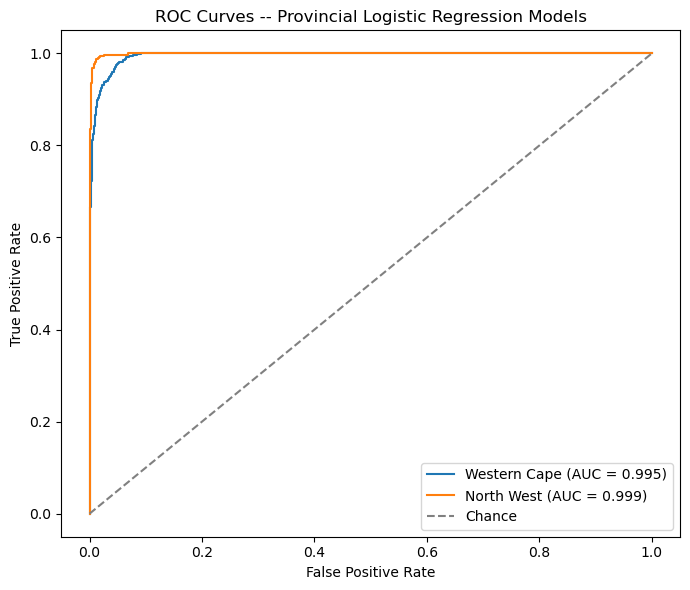

In [27]:
wc_fpr, wc_tpr, _ = roc_curve(WC_y_val, wc_y_prob)
nw_fpr, nw_tpr, _ = roc_curve(NW_y_val, nw_y_prob)

plt.figure(figsize=(7, 6))
plt.plot(wc_fpr, wc_tpr, label=f"Western Cape (AUC = {roc_auc_score(WC_y_val, wc_y_prob):.3f})")
plt.plot(nw_fpr, nw_tpr, label=f"North West (AUC = {roc_auc_score(NW_y_val, nw_y_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves -- Provincial Logistic Regression Models")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Decision Tree — combined provinces

The decision tree uses candidates from **both** provinces together, with a `Province_WesternCape` indicator added as a predictor so the tree can split on province if that turns out to be informative. `max_depth` and `min_samples_leaf` are set to keep the tree readable — feel free to loosen these if you want the tree to explore more splits.

In [28]:
model_pop["Province_WesternCape"] = (model_pop["Province"] == "Western Cape").astype(int)
tree_predictors = predictors + ["Province_WesternCape"]

X_all = model_pop[tree_predictors]
y_all = model_pop[target]

X_train_all, X_val_all, y_train_all, y_val_all = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)

print(f"Combined modelling data: {len(model_pop)} candidates "
      f"-> {len(X_train_all)} train / {len(X_val_all)} validation")

Combined modelling data: 26418 candidates -> 18492 train / 7926 validation


In [29]:
decision_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=RANDOM_STATE
)
decision_tree.fit(X_train_all, y_train_all)

tree_y_pred = decision_tree.predict(X_val_all)
tree_y_prob = decision_tree.predict_proba(X_val_all)[:, 1]

print("Combined decision tree -- validation performance")
print("Accuracy: ", accuracy_score(y_val_all, tree_y_pred))
print("Precision:", precision_score(y_val_all, tree_y_pred))
print("Recall:   ", recall_score(y_val_all, tree_y_pred))
print("ROC-AUC:  ", roc_auc_score(y_val_all, tree_y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val_all, tree_y_pred))
print("\nClassification Report:")
print(classification_report(y_val_all, tree_y_pred))

Combined decision tree -- validation performance
Accuracy:  0.9967196568256371
Precision: 0.997887323943662
Recall:    0.9840277777777777
ROC-AUC:   0.9995891257237811

Confusion Matrix:
[[6483    3]
 [  23 1417]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6486
           1       1.00      0.98      0.99      1440

    accuracy                           1.00      7926
   macro avg       1.00      0.99      0.99      7926
weighted avg       1.00      1.00      1.00      7926



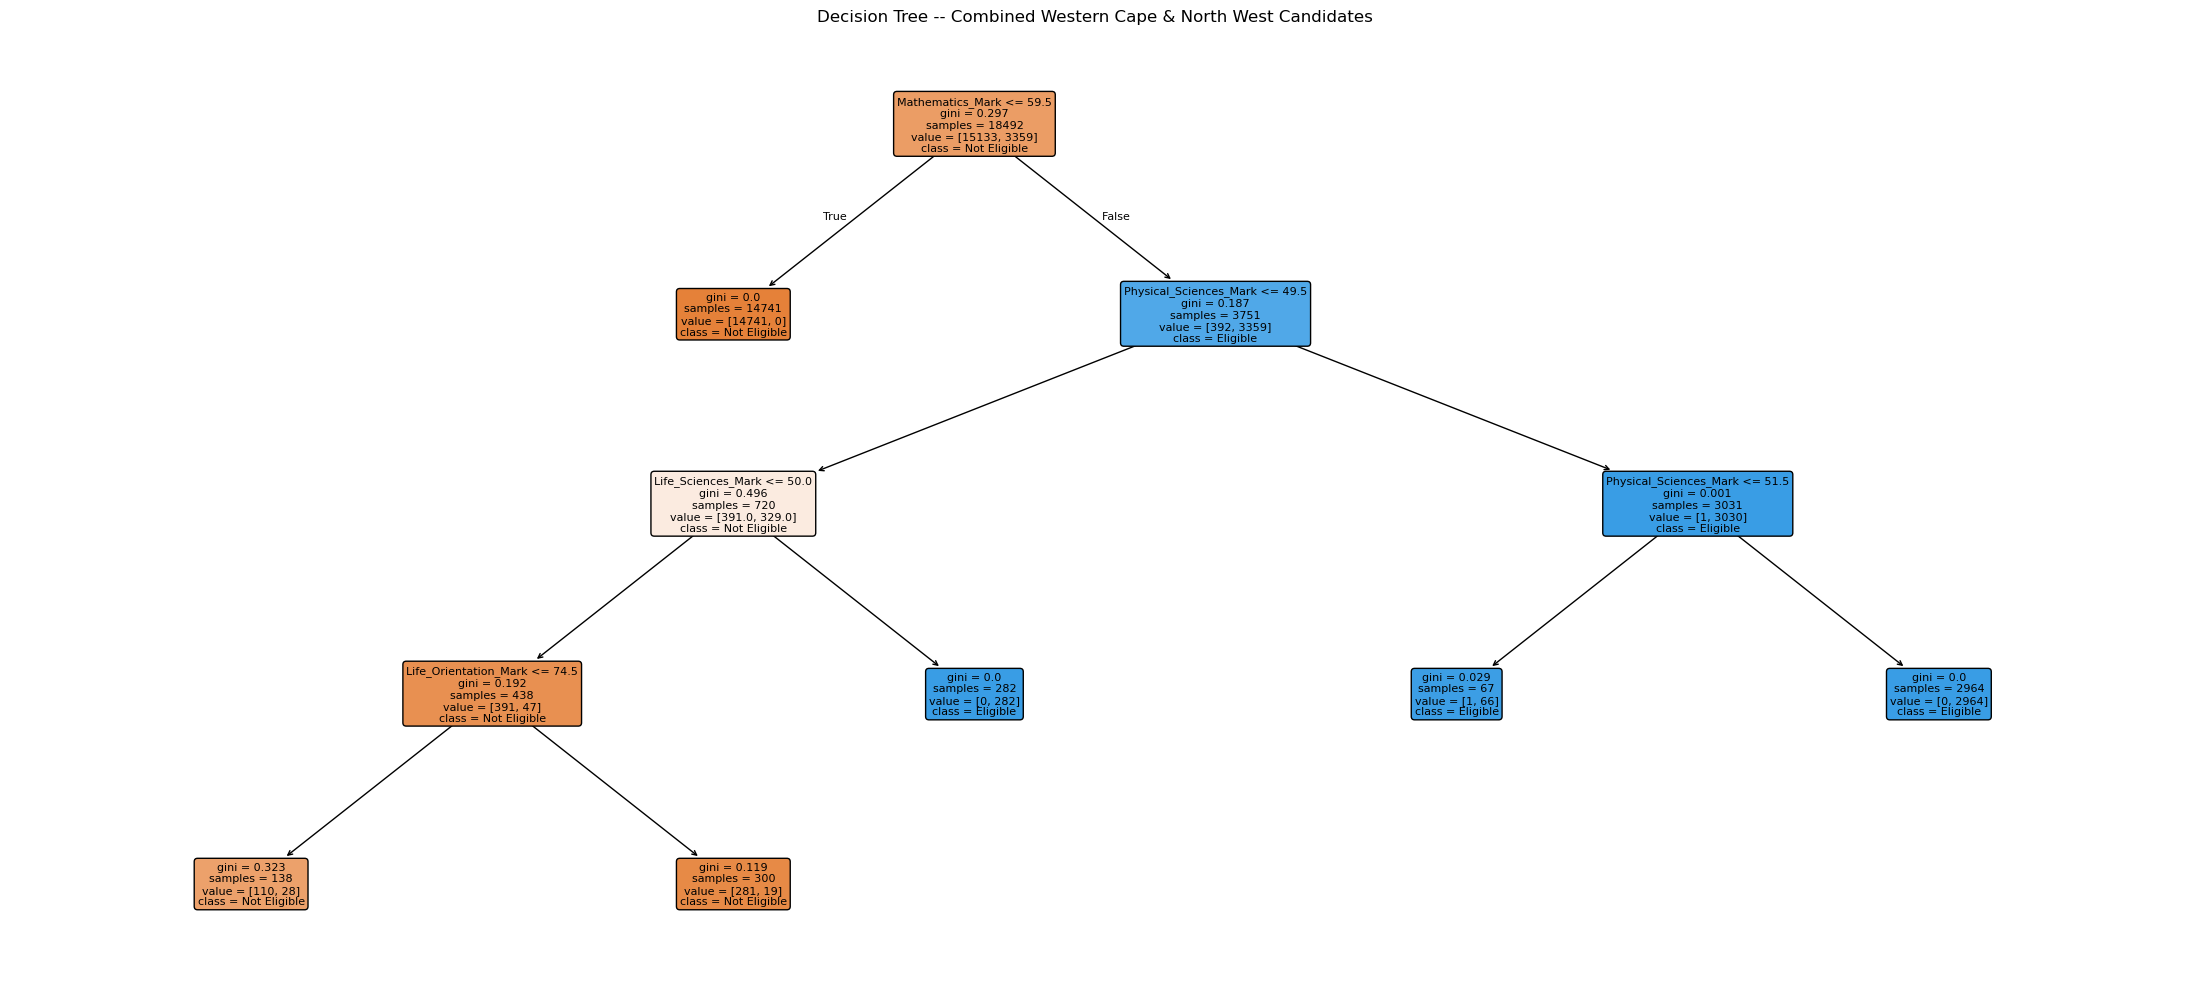

In [30]:
plt.figure(figsize=(22, 10))
plot_tree(
    decision_tree,
    feature_names=tree_predictors,
    class_names=["Not Eligible", "Eligible"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree -- Combined Western Cape & North West Candidates")
plt.tight_layout()
plt.show()

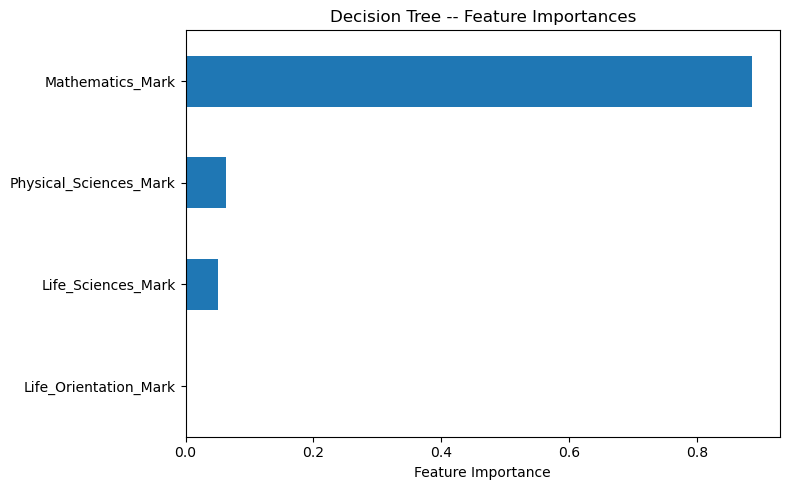

Mathematics_Mark               0.885538
Physical_Sciences_Mark         0.063294
Life_Sciences_Mark             0.050488
Life_Orientation_Mark          0.000680
English_Mark                   0.000000
Second_Language_Mark           0.000000
Took_Physical_Sciences         0.000000
Took_Life_Sciences             0.000000
Information_Technology_Mark    0.000000
Took_Information_Technology    0.000000
Num_Subjects_Recorded          0.000000
Centre_type_Independent        0.000000
Gender_Male                    0.000000
Province_WesternCape           0.000000
dtype: float64

In [31]:
feature_importance = (
    pd.Series(decision_tree.feature_importances_, index=tree_predictors)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
feature_importance[feature_importance > 0].plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Decision Tree -- Feature Importances")
plt.tight_layout()
plt.show()

feature_importance

## 11. Summary & limitations

- **Modelling population:** candidates with a recorded `Mathematics_Mark` (pure Maths), which automatically excludes Mathematical Literacy candidates and the small "neither" group, both of which are already 100% ineligible in the raw data.
- **All subject combinations are retained** — the model is no longer restricted to Physical Sciences + Life Sciences + IT takers only; `Took_<Subject>` indicators plus 0-filled marks let the model make use of candidates who chose different electives.
- **Mathematics performance dominates eligibility** in both provinces and in the combined decision tree (by a wide margin in feature importance) — this reflects how the APS/subject-requirement rules are actually constructed, not a modelling artefact, but it does produce quasi-complete separation in the logistic regressions, so p-values near that boundary should be read cautiously.
- **VIF flags** `Information_Technology_Mark` / `Took_Information_Technology` (and to a lesser extent the Physical/Life Sciences pairs) as moderately collinear, mostly because IT is a rare subject choice — consider dropping the `Took_` flag for IT if a stricter multicollinearity threshold is required.
- **`Race` was deliberately excluded** from the predictor set on fairness grounds; it remains in `model_pop` if a demographic-disparity analysis is explicitly required.
- **`NR` was dropped** for being effectively identical (0.99 correlation) to `Num_Subjects_Recorded`.